# 🫁 LBC Mortality Rate — ML Dashboard
**Lung & Bronchus Cancer (LBC) Mortality Rate Prediction**

Reproducible pipeline covering:
1. Configuration & data loading
2. Exploratory data analysis (EDA)
3. Data splitting strategies
4. Covariate selection
5. Model training (9 base models + ensemble stacking)
6. Performance metrics & comparison
7. Variable importance (Pearson, permutation, SHAP, coefficients)

> **To use with a different dataset:** update the `CONFIG` cell (Section 1). All downstream cells adapt automatically.


## 0. Install dependencies

In [3]:
# Run once – safe to skip if packages are already installed
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn \
    xgboost lightgbm shap scipy statsmodels pygam --quiet


## 1. Configuration
Edit **`CONFIG`** to adapt this notebook to a different dataset. All subsequent cells read from this dict.


In [4]:
CONFIG = {
    # ── Data ──────────────────────────────────────────────────────────────────
    "data_path":      "data_1998_2010_long_lbc.csv",   # CSV path (local or URL)
    "target":         "RATE",                           # Column to predict
    "id_cols":        ["FIPS"],                         # ID columns to drop before modelling
    "spatial_cols":   ["X", "Y"],                       # Spatial coordinate columns
    "temporal_col":   "Year",                           # Temporal column (None if absent)

    # ── Covariates (None = use all non-id, non-target columns) ─────────────
    "selected_features": ["SMOKING", "POVERTY", "PM25", "NO2", "SO2", "Year"],

    # ── Splitting ─────────────────────────────────────────────────────────────
    "split_strategy": "temporal",   # "random" | "temporal" | "spatial" | "kfold"
    "train_frac":     0.70,
    "val_frac":       0.15,         # remainder becomes test
    "n_folds":        5,            # used when split_strategy == "kfold"
    "random_seed":    42,

    # ── Year filter (None = all years) ────────────────────────────────────────
    # Set to a single int (e.g. 2005), "mean" (per-county avg), or None
    "year_filter":    None,

    # ── Models to train (True = include) ─────────────────────────────────────
    "models": {
        "OLS":              True,
        "Ridge":            True,
        "Lasso":            True,
        "RandomForest":     True,
        "GradientBoosting": True,
        "SVR":              False,
        "kNN":              False,
        "NeuralNet":        False,
        "GAM":              False,
    },

    # ── Ensemble stacking ─────────────────────────────────────────────────────
    "ensemble": {
        "enabled":          True,
        "strategy":         "stacking",    # "stacking" | "blending" | "voting" | "bagging"
        "base_learners":    ["Ridge", "RandomForest", "GradientBoosting"],
        "meta_learner":     "Ridge",       # any sklearn-compatible regressor name
        "cv_folds":         5,
        "use_orig_features": True,         # pass raw features to meta-learner too
        "weights":          None,          # dict {model: weight} for voting; None = equal
    },

    # ── Metrics ───────────────────────────────────────────────────────────────
    "metrics": ["RMSE", "MAE", "R2", "MAPE", "MedAE"],
    "rank_by":  "RMSE",

    # ── Plots ─────────────────────────────────────────────────────────────────
    "fig_dpi":    120,
    "palette":    "Blues",   # seaborn palette for heatmaps
}

print("Configuration loaded ✓")
print(f"  Target       : {CONFIG['target']}")
print(f"  Features     : {CONFIG['selected_features']}")
print(f"  Split        : {CONFIG['split_strategy']} — train {CONFIG['train_frac']:.0%} / val {CONFIG['val_frac']:.0%} / test {1-CONFIG['train_frac']-CONFIG['val_frac']:.0%}")
print(f"  Year filter  : {CONFIG['year_filter']}")
print(f"  Ensemble     : {'enabled (' + CONFIG['ensemble']['strategy'] + ')' if CONFIG['ensemble']['enabled'] else 'disabled'}")


Configuration loaded ✓
  Target       : RATE
  Features     : ['SMOKING', 'POVERTY', 'PM25', 'NO2', 'SO2', 'Year']
  Split        : temporal — train 70% / val 15% / test 15%
  Year filter  : None
  Ensemble     : enabled (stacking)


## 2. Imports & helper utilities

In [5]:
import warnings, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from sklearn.model_selection import KFold, train_test_split, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              BaggingRegressor, VotingRegressor, StackingRegressor)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score, median_absolute_error,
                              mean_absolute_percentage_error)

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    from pygam import LinearGAM, s
    HAS_GAM = True
except ImportError:
    HAS_GAM = False

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

plt.rcParams.update({
    "figure.dpi": CONFIG["fig_dpi"],
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
SEED = CONFIG["random_seed"]

# ── Metric helpers ─────────────────────────────────────────────────────────
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape_safe(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

METRIC_FNS = {
    "RMSE":  rmse,
    "MAE":   mean_absolute_error,
    "R2":    r2_score,
    "MAPE":  mape_safe,
    "MedAE": median_absolute_error,
}

def evaluate(y_true, y_pred, metrics=None):
    metrics = metrics or CONFIG["metrics"]
    return {m: round(METRIC_FNS[m](y_true, y_pred), 4) for m in metrics if m in METRIC_FNS}

print("Imports complete ✓")
print(f"  SHAP available : {HAS_SHAP}")
print(f"  XGBoost        : {HAS_XGB}")
print(f"  PyGAM          : {HAS_GAM}")


Imports complete ✓
  SHAP available : True
  XGBoost        : True
  PyGAM          : True


## 3. Data loading & year filter

In [6]:
df_raw = pd.read_csv(CONFIG["data_path"])
print(f"Loaded  {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Columns : {list(df_raw.columns)}")
print()

# ── Apply year filter ──────────────────────────────────────────────────────
yf = CONFIG["year_filter"]
tcol = CONFIG["temporal_col"]

if yf is None:
    df = df_raw.copy()
    filter_label = "All years"

elif yf == "mean":
    # Aggregate to per-county means across all years
    group_cols = [c for c in df_raw.columns
                  if c not in ([CONFIG["target"], tcol] + CONFIG["id_cols"])]
    df = df_raw.groupby(CONFIG["id_cols"] + [c for c in ["X","Y"] if c in df_raw.columns],
                        as_index=False).mean(numeric_only=True)
    # Drop Year column if present (no longer meaningful)
    if tcol in df.columns:
        df = df.drop(columns=[tcol])
    filter_label = "Per-county means (all years)"

else:
    df = df_raw[df_raw[tcol] == int(yf)].copy()
    filter_label = f"Year = {yf}"

print(f"Year filter : {filter_label}")
print(f"Working set : {df.shape[0]:,} rows × {df.shape[1]} columns")
print()
df.describe().round(2)


Loaded  46,605 rows × 10 columns
Columns : ['FIPS', 'X', 'Y', 'Year', 'SMOKING', 'POVERTY', 'PM25', 'NO2', 'SO2', 'RATE']

Year filter : All years
Working set : 46,605 rows × 10 columns



,FIPS,X,Y,Year,SMOKING,POVERTY,PM25,NO2,SO2,RATE
count,46605.00,46605.00,46605.00,46605.00,46605.00,46605.00,46605.00,46605.00,46605.00,46605.00
mean,30666.87,387333.70,1761335.86,2005.00,25.78,14.84,9.87,1.55,0.04,65.91
std,14981.37,965741.77,559176.97,4.32,4.04,6.01,3.50,1.39,0.06,16.80
min,1001.00,-2303830.44,343702.67,1998.00,7.10,1.70,1.04,0.06,0.00,11.18
25%,19043.00,-171368.89,1340753.45,2001.00,23.20,10.60,7.21,0.65,0.00,54.00
50%,29211.00,505203.32,1772684.13,2005.00,25.90,13.90,9.66,1.10,0.02,65.39
75%,46007.00,1121743.84,2160297.04,2009.00,28.50,18.10,12.24,1.97,0.05,76.83
max,56045.00,2200344.81,3126214.37,2012.00,44.00,62.00,26.05,21.56,0.63,223.60


## 4. Exploratory data analysis

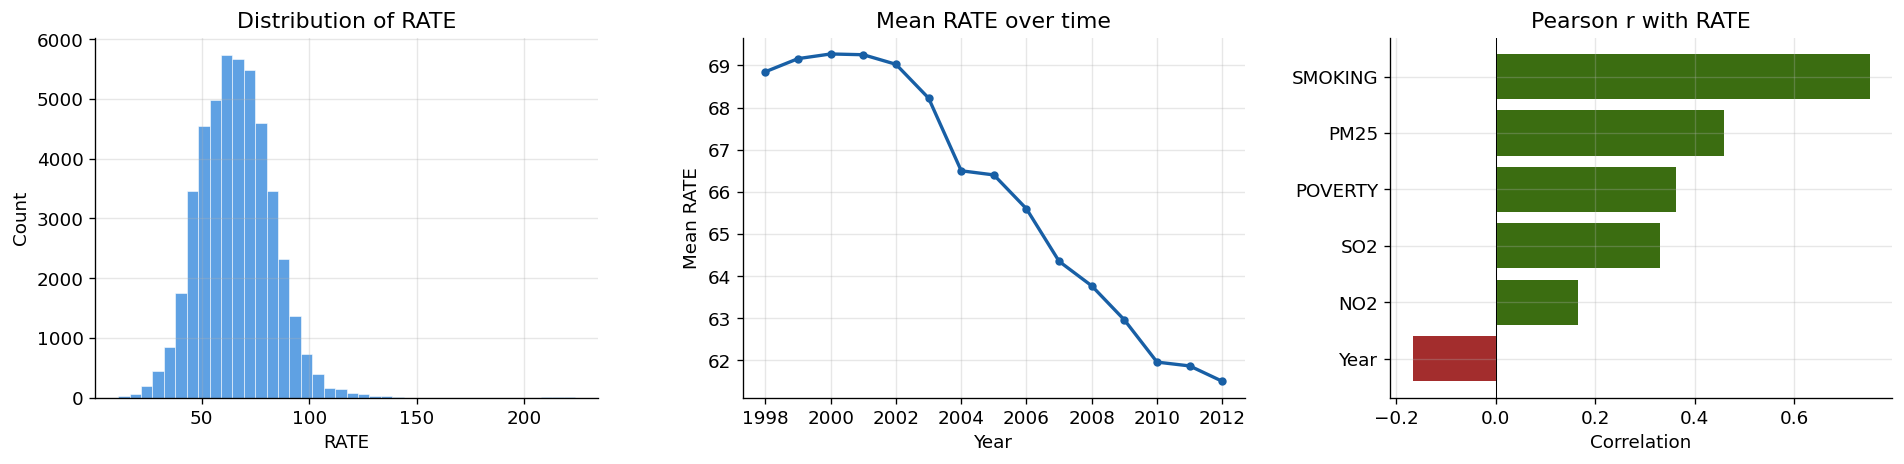

Saved → eda_overview.png


In [7]:
target = CONFIG["target"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 4a. RATE distribution
axes[0].hist(df[target].dropna(), bins=40, color="#378ADD", alpha=0.8, edgecolor="white", linewidth=0.4)
axes[0].set_title(f"Distribution of {target}")
axes[0].set_xlabel(target); axes[0].set_ylabel("Count")

# 4b. RATE over time (if temporal column present)
if tcol in df.columns:
    trend = df.groupby(tcol)[target].mean()
    axes[1].plot(trend.index, trend.values, marker="o", color="#185FA5", linewidth=2, markersize=4)
    axes[1].set_title(f"Mean {target} over time")
    axes[1].set_xlabel(tcol); axes[1].set_ylabel(f"Mean {target}")
else:
    axes[1].text(0.5, 0.5, "No temporal column", ha="center", va="center",
                 transform=axes[1].transAxes, color="gray")
    axes[1].set_title("Temporal trend"); axes[1].axis("off")

# 4c. Correlation with RATE
feat_cols = [c for c in CONFIG["selected_features"] if c in df.columns]
corrs = df[feat_cols + [target]].corr()[target].drop(target).sort_values()
colors = ["#3B6D11" if v > 0 else "#A32D2D" for v in corrs]
axes[2].barh(corrs.index, corrs.values, color=colors)
axes[2].axvline(0, color="black", linewidth=0.6)
axes[2].set_title(f"Pearson r with {target}")
axes[2].set_xlabel("Correlation")

plt.tight_layout()
plt.savefig("eda_overview.png", bbox_inches="tight")
plt.show()
print("Saved → eda_overview.png")


In [8]:
# ── Descriptive statistics ─────────────────────────────────────────────────
desc_cols = [c for c in CONFIG["selected_features"] if c in df.columns] + [target]
stats_df = df[desc_cols].describe().T.round(3)
stats_df.columns = stats_df.columns.str.capitalize()
print("Descriptive statistics")
print(stats_df.to_string())


Descriptive statistics
           Count      Mean     Std      Min       25%       50%      75%       Max
SMOKING  46605.0    25.777   4.037     7.10    23.200    25.900    28.50    44.000
POVERTY  46605.0    14.840   6.014     1.70    10.600    13.900    18.10    62.000
PM25     46605.0     9.871   3.495     1.04     7.210     9.660    12.24    26.050
NO2      46605.0     1.547   1.388     0.06     0.650     1.100     1.97    21.560
SO2      46605.0     0.040   0.064     0.00     0.003     0.016     0.05     0.632
Year     46605.0  2005.000   4.321  1998.00  2001.000  2005.000  2009.00  2012.000
RATE     46605.0    65.913  16.804    11.18    54.000    65.390    76.83   223.600


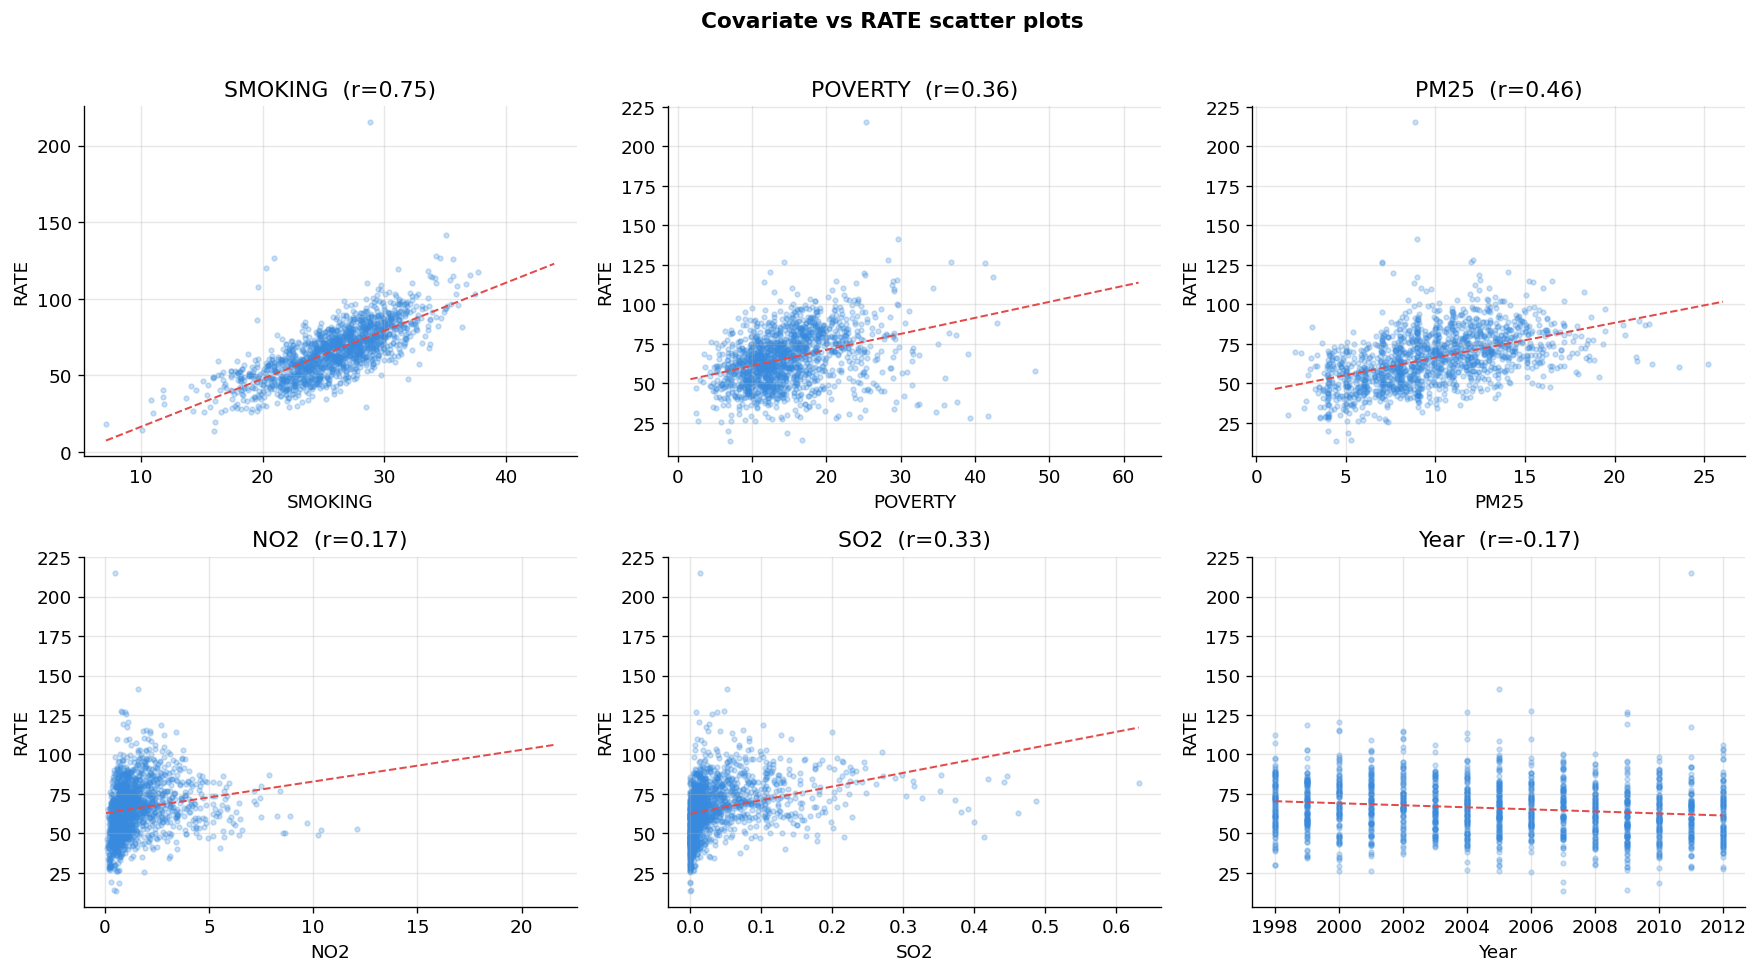

Saved → scatter_matrix.png


In [9]:
# ── Scatter matrix (selected features vs RATE) ────────────────────────────
sample = df[feat_cols + [target]].sample(min(1500, len(df)), random_state=SEED)

n = len(feat_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = np.array(axes).flatten()

for i, feat in enumerate(feat_cols):
    axes[i].scatter(sample[feat], sample[target], alpha=0.25, s=8, color="#378ADD")
    m, b, r, p, _ = stats.linregress(df[feat].dropna(), df[target][df[feat].notna()])
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    axes[i].plot(x_line, m*x_line + b, color="#E24B4A", linewidth=1.2, linestyle="--")
    axes[i].set_xlabel(feat); axes[i].set_ylabel(target)
    axes[i].set_title(f"{feat}  (r={r:.2f})")

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.suptitle(f"Covariate vs {target} scatter plots", y=1.01, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("scatter_matrix.png", bbox_inches="tight")
plt.show()
print("Saved → scatter_matrix.png")


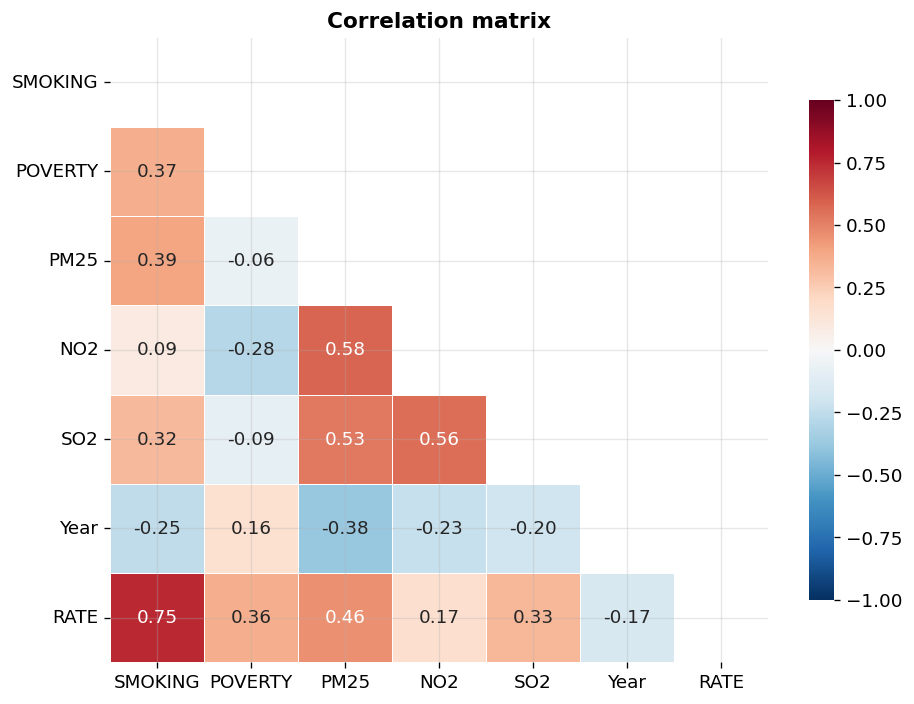

Saved → correlation_heatmap.png


In [10]:
# ── Correlation heatmap ────────────────────────────────────────────────────
corr_matrix = df[feat_cols + [target]].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
ax.set_title("Correlation matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()
print("Saved → correlation_heatmap.png")


## 5. Data splitting

Feature matrix : (46605, 6)
Target vector  : (46605,)
Features used  : ['SMOKING', 'POVERTY', 'PM25', 'NO2', 'SO2', 'Year']

Strategy : Temporal split — train < 2008 / val [2008,2010) / test >= 2010
  Train  : 31,070 rows
  Val    : 6,214 rows
  Test   : 9,321 rows


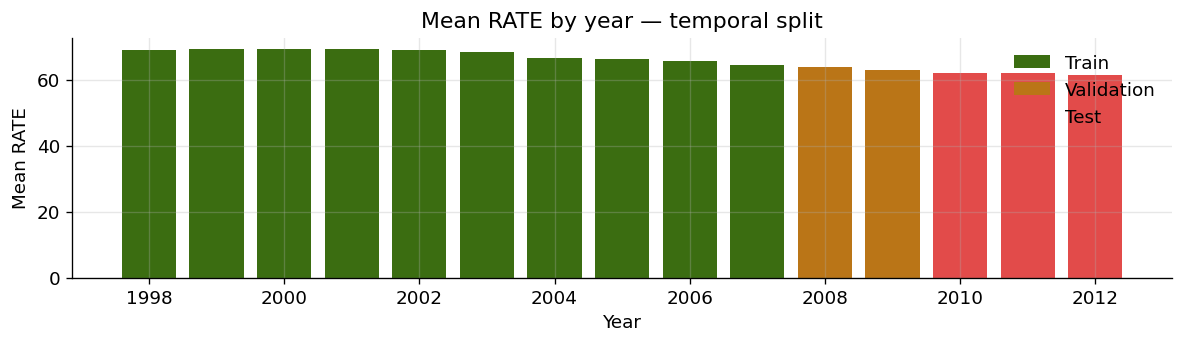

Saved → temporal_split.png


In [11]:
strategy  = CONFIG["split_strategy"]
train_f   = CONFIG["train_frac"]
val_f     = CONFIG["val_frac"]
test_f    = 1 - train_f - val_f
n_folds   = CONFIG["n_folds"]

# ── Select feature matrix X and target y ──────────────────────────────────
drop_cols = CONFIG["id_cols"] + [target]
drop_cols += [c for c in ["X","Y"] if c in df.columns and c not in feat_cols]
X = df[[c for c in feat_cols if c in df.columns]].copy()
y = df[target].copy()

print(f"Feature matrix : {X.shape}")
print(f"Target vector  : {y.shape}")
print(f"Features used  : {list(X.columns)}")
print()

if strategy == "random":
    X_tr_val, X_test, y_tr_val, y_test = train_test_split(
        X, y, test_size=test_f, random_state=SEED)
    val_share = val_f / (train_f + val_f)
    X_train, X_val, y_train, y_val = train_test_split(
        X_tr_val, y_tr_val, test_size=val_share, random_state=SEED)
    splits_info = f"Random split — train {train_f:.0%} / val {val_f:.0%} / test {test_f:.0%}"

elif strategy == "temporal" and tcol in df.columns:
    years_sorted = sorted(df[tcol].unique())
    n_yr = len(years_sorted)
    train_cut = years_sorted[int(n_yr * train_f)]
    val_cut   = years_sorted[int(n_yr * (train_f + val_f))]
    train_mask = df[tcol] <  train_cut
    val_mask   = (df[tcol] >= train_cut) & (df[tcol] < val_cut)
    test_mask  = df[tcol] >= val_cut
    X_train, y_train = X[train_mask], y[train_mask]
    X_val,   y_val   = X[val_mask],   y[val_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]
    splits_info = f"Temporal split — train < {train_cut} / val [{train_cut},{val_cut}) / test >= {val_cut}"

elif strategy == "kfold":
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    # For kfold we still keep a held-out test set (20%)
    X_rest, X_test, y_rest, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED)
    X_train, X_val = X_rest, X_rest   # val = same as train; CV done inside model training
    y_train, y_val = y_rest, y_rest
    splits_info = f"{n_folds}-Fold CV — test holdout 20%"

else:  # fallback to random
    X_tr_val, X_test, y_tr_val, y_test = train_test_split(X, y, test_size=test_f, random_state=SEED)
    val_share = val_f / (train_f + val_f)
    X_train, X_val, y_train, y_val = train_test_split(X_tr_val, y_tr_val, test_size=val_share, random_state=SEED)
    splits_info = "Random split (fallback)"

print(f"Strategy : {splits_info}")
print(f"  Train  : {len(X_train):,} rows")
print(f"  Val    : {len(X_val):,} rows")
print(f"  Test   : {len(X_test):,} rows")

# ── Visualise split (temporal only) ───────────────────────────────────────
if strategy == "temporal" and tcol in df.columns:
    fig, ax = plt.subplots(figsize=(10, 3))
    def plot_split_bar(mask, color, label):
        sub = df[mask].groupby(tcol)[target].mean()
        ax.bar(sub.index, sub.values, color=color, label=label, width=0.8)
    plot_split_bar(train_mask, "#3B6D11", "Train")
    plot_split_bar(val_mask,   "#BA7517", "Validation")
    plot_split_bar(test_mask,  "#E24B4A", "Test")
    ax.set_xlabel(tcol); ax.set_ylabel(f"Mean {target}")
    ax.set_title(f"Mean {target} by year — temporal split")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.savefig("temporal_split.png", bbox_inches="tight")
    plt.show()
    print("Saved → temporal_split.png")


## 6. Model registry & training

In [12]:
# ── Model registry ────────────────────────────────────────────────────────
def make_model(name):
    """Return a sklearn-compatible Pipeline with StandardScaler + regressor."""
    regs = {
        "OLS":              LinearRegression(),
        "Ridge":            Ridge(alpha=1.0, random_state=SEED),
        "Lasso":            Lasso(alpha=0.1, random_state=SEED, max_iter=5000),
        "ElasticNet":       ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=SEED),
        "RandomForest":     RandomForestRegressor(n_estimators=200, max_features="sqrt",
                                                   random_state=SEED, n_jobs=-1),
        "GradientBoosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                       max_depth=4, random_state=SEED),
        "SVR":              SVR(kernel="rbf", C=10, epsilon=0.5),
        "kNN":              KNeighborsRegressor(n_neighbors=10, weights="distance"),
        "NeuralNet":        MLPRegressor(hidden_layer_sizes=(128,64), max_iter=500,
                                         random_state=SEED, early_stopping=True),
        "GAM":              None,   # handled separately
    }
    reg = regs.get(name)
    if reg is None:
        raise ValueError(f"Unknown model: {name}")
    return Pipeline([("scaler", StandardScaler()), ("model", reg)])

enabled = {k for k, v in CONFIG["models"].items() if v}
print(f"Models enabled : {sorted(enabled)}")


Models enabled : ['GradientBoosting', 'Lasso', 'OLS', 'RandomForest', 'Ridge']


In [14]:
# ── Train all selected base models ────────────────────────────────────────
trained_models = {}
results_val    = {}
results_test   = {}

for name in sorted(enabled):
    print(f"Training {name}...", end=" ")

    if name == "GAM":
        if not HAS_GAM:
            print("skipped (PyGAM not installed)")
            continue
        scaler = StandardScaler()
        Xt = scaler.fit_transform(X_train)
        Xv = scaler.transform(X_val)
        Xte = scaler.transform(X_test)
        terms = sum(s(i) for i in range(Xt.shape[1]))
        model = LinearGAM(terms).fit(Xt, y_train)
        val_pred  = model.predict(Xv)
        test_pred = model.predict(Xte)
        # wrap for later use
        class GAMWrapper:
            def __init__(self, gam, sc): self.gam=gam; self.sc=sc
            def predict(self, X): return self.gam.predict(self.sc.transform(X))
        trained_models[name] = GAMWrapper(model, scaler)
    else:
        pipe = make_model(name)
        pipe.fit(X_train, y_train)
        val_pred  = pipe.predict(X_val)
        test_pred = pipe.predict(X_test)
        trained_models[name] = pipe

    results_val[name]  = evaluate(y_val.values,  val_pred)
    results_test[name] = evaluate(y_test.values, test_pred)
    print(f"RMSE_val={results_val[name]['RMSE']:.3f}  R²={results_val[name]['R2']:.3f}")

print()
print(f"Trained {len(trained_models)} models ✓")


Training GradientBoosting... RMSE_val=10.408  R²=0.615
Training Lasso... RMSE_val=10.851  R²=0.582
Training OLS... RMSE_val=10.801  R²=0.586
Training RandomForest... RMSE_val=10.529  R²=0.607
Training Ridge... RMSE_val=10.801  R²=0.586

Trained 5 models ✓


## 7. Ensemble stacking

In [15]:
ens_cfg  = CONFIG["ensemble"]
ens_name = None

if ens_cfg["enabled"]:
    strategy_ens = ens_cfg["strategy"]
    base_names   = [b for b in ens_cfg["base_learners"] if b in trained_models]
    meta_name    = ens_cfg["meta_learner"]
    cv_folds_ens = ens_cfg["cv_folds"]
    use_orig     = ens_cfg["use_orig_features"]

    print(f"Ensemble strategy : {strategy_ens}")
    print(f"Base learners     : {base_names}")
    print(f"Meta-learner      : {meta_name}")
    print()

    if len(base_names) < 2:
        print("⚠ Need at least 2 base learners for ensemble. Skipping.")
    else:
        if strategy_ens in ("stacking", "blending"):
            # ── Build out-of-fold meta-features ───────────────────────────
            if strategy_ens == "stacking":
                kf_ens = KFold(n_splits=cv_folds_ens, shuffle=True, random_state=SEED)
                meta_train = np.zeros((len(X_train), len(base_names)))
                for j, bname in enumerate(base_names):
                    pipe_b = make_model(bname)
                    oof = cross_val_predict(pipe_b, X_train, y_train,
                                            cv=kf_ens, n_jobs=-1)
                    meta_train[:, j] = oof
            else:  # blending — use validation set as meta-training
                meta_train = np.column_stack([
                    trained_models[b].predict(X_val) for b in base_names
                ])
                y_meta = y_val.values

            if use_orig:
                scaler_orig = StandardScaler()
                Xtr_orig = scaler_orig.fit_transform(X_train if strategy_ens=="stacking" else X_val)
                meta_train = np.hstack([meta_train, Xtr_orig])

            y_meta_fit = y_train.values if strategy_ens == "stacking" else y_val.values

            # ── Meta-learner ──────────────────────────────────────────────
            meta_map = {
                "Ridge": Ridge(alpha=1.0), "Lasso": Lasso(alpha=0.05),
                "LinearRegression": LinearRegression(),
                "ElasticNet": ElasticNet(alpha=0.05, l1_ratio=0.5),
                "RandomForest": RandomForestRegressor(n_estimators=100, random_state=SEED),
                "GradientBoosting": GradientBoostingRegressor(n_estimators=100, random_state=SEED),
            }
            meta_reg = meta_map.get(meta_name, Ridge(alpha=1.0))
            meta_reg.fit(meta_train, y_meta_fit)

            # ── Predict on val & test ─────────────────────────────────────
            def ens_predict(X_in):
                base_preds = np.column_stack([trained_models[b].predict(X_in) for b in base_names])
                if use_orig:
                    base_preds = np.hstack([base_preds, scaler_orig.transform(X_in)])
                return meta_reg.predict(base_preds)

            val_pred_ens  = ens_predict(X_val)
            test_pred_ens = ens_predict(X_test)

        elif strategy_ens == "voting":
            weights = ens_cfg.get("weights")
            w_arr = None
            if weights:
                w_arr = [weights.get(b, 1.0) for b in base_names]
            val_preds_all  = np.column_stack([trained_models[b].predict(X_val)  for b in base_names])
            test_preds_all = np.column_stack([trained_models[b].predict(X_test) for b in base_names])
            if w_arr:
                w_arr = np.array(w_arr) / np.sum(w_arr)
                val_pred_ens  = val_preds_all  @ w_arr
                test_pred_ens = test_preds_all @ w_arr
            else:
                val_pred_ens  = val_preds_all.mean(axis=1)
                test_pred_ens = test_preds_all.mean(axis=1)

        elif strategy_ens == "bagging":
            base_pipe = make_model(base_names[0])
            bag = BaggingRegressor(estimator=base_pipe.named_steps["model"],
                                   n_estimators=30, random_state=SEED, n_jobs=-1)
            scaler_bag = StandardScaler()
            bag.fit(scaler_bag.fit_transform(X_train), y_train)
            val_pred_ens  = bag.predict(scaler_bag.transform(X_val))
            test_pred_ens = bag.predict(scaler_bag.transform(X_test))

        else:
            val_pred_ens  = np.mean([trained_models[b].predict(X_val)  for b in base_names], axis=0)
            test_pred_ens = np.mean([trained_models[b].predict(X_test) for b in base_names], axis=0)

        ens_name = f"Ensemble ({strategy_ens})"
        results_val[ens_name]  = evaluate(y_val.values,  val_pred_ens)
        results_test[ens_name] = evaluate(y_test.values, test_pred_ens)
        print(f"{ens_name} — RMSE_val={results_val[ens_name]['RMSE']:.3f}  R²={results_val[ens_name]['R2']:.3f}")
else:
    print("Ensemble disabled — skipping.")


Ensemble strategy : stacking
Base learners     : ['Ridge', 'RandomForest', 'GradientBoosting']
Meta-learner      : Ridge

Ensemble (stacking) — RMSE_val=10.735  R²=0.591


## 8. Performance metrics & comparison

In [16]:
# ── Results table ─────────────────────────────────────────────────────────
val_df  = pd.DataFrame(results_val).T.rename_axis("Model").reset_index()
test_df = pd.DataFrame(results_test).T.rename_axis("Model").reset_index()

rank_col = CONFIG["rank_by"]
val_df_sorted  = val_df.sort_values(rank_col, ascending=(rank_col != "R2")).reset_index(drop=True)
test_df_sorted = test_df.sort_values(rank_col, ascending=(rank_col != "R2")).reset_index(drop=True)

print("=== Validation set ===")
print(val_df_sorted.to_string(index=False))
print()
print("=== Test set ===")
print(test_df_sorted.to_string(index=False))


=== Validation set ===
              Model    RMSE    MAE     R2    MAPE  MedAE
   GradientBoosting 10.4084 7.7797 0.6154 12.3972 6.3230
       RandomForest 10.5287 7.7569 0.6065 12.4057 6.1817
Ensemble (stacking) 10.7351 7.8787 0.5909 12.5388 6.1813
                OLS 10.8012 8.1239 0.5858 13.5764 6.6961
              Ridge 10.8012 8.1239 0.5858 13.5764 6.6956
              Lasso 10.8505 8.1671 0.5820 13.6045 6.7385

=== Test set ===
              Model    RMSE    MAE     R2    MAPE  MedAE
   GradientBoosting  9.9842 7.3949 0.6562 12.4366 6.0023
       RandomForest 10.0305 7.4606 0.6530 12.7378 6.0454
Ensemble (stacking) 10.1966 7.5888 0.6415 12.8928 6.1327
                OLS 10.4950 7.7894 0.6202 13.5504 6.1885
              Ridge 10.4950 7.7894 0.6202 13.5504 6.1885
              Lasso 10.5449 7.8291 0.6165 13.5482 6.2608


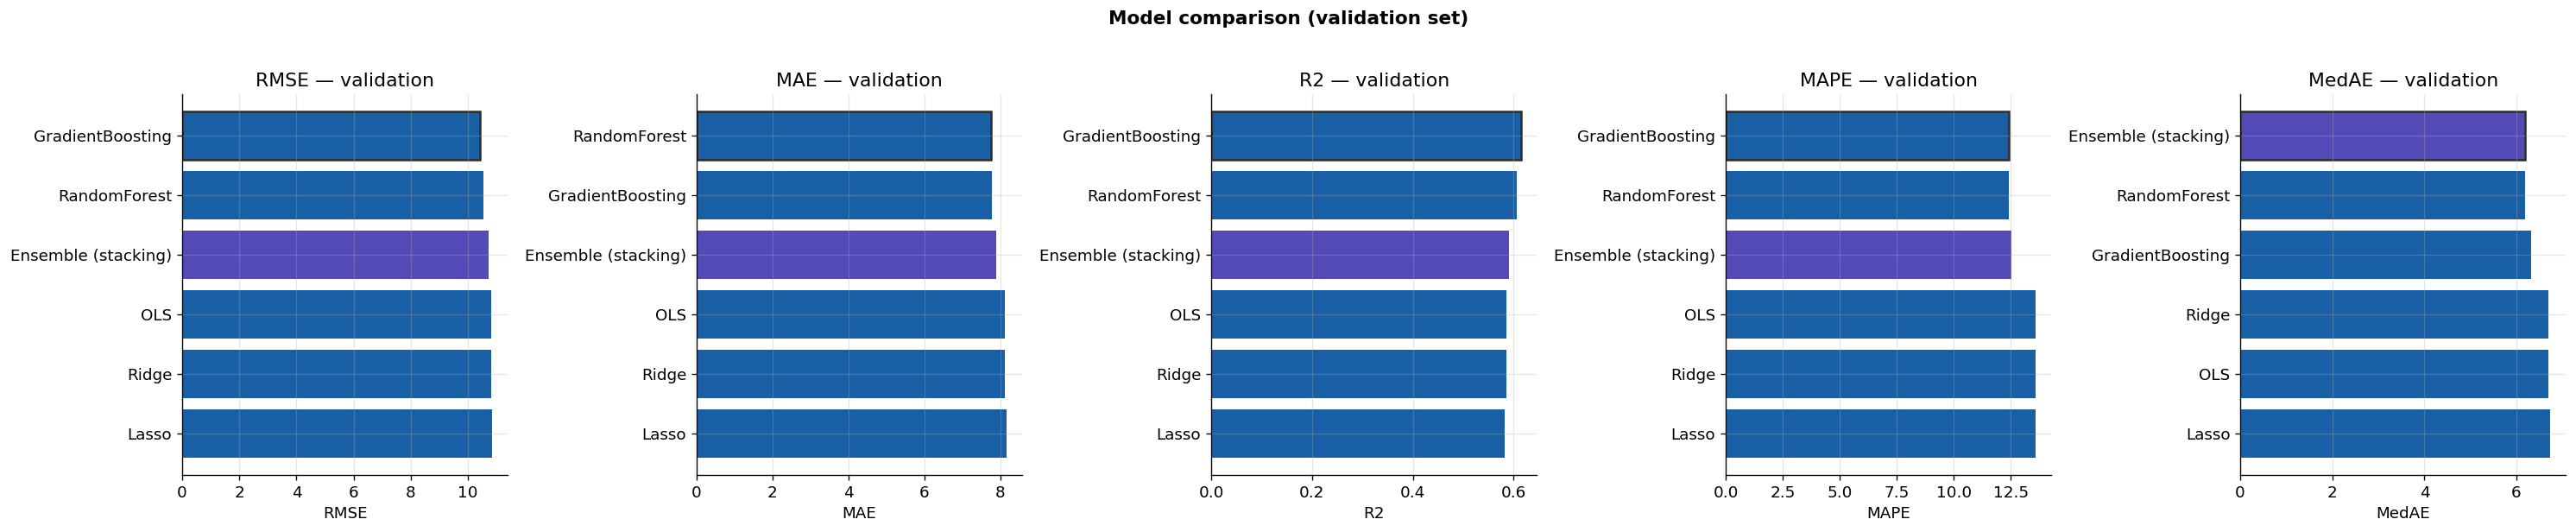

Saved → model_comparison.png


In [17]:
# ── Comparison charts ─────────────────────────────────────────────────────
metrics_plot = [m for m in CONFIG["metrics"] if m in val_df.columns]
fig, axes = plt.subplots(1, len(metrics_plot), figsize=(5*len(metrics_plot), 5))
if len(metrics_plot) == 1: axes = [axes]

ens_mask = val_df_sorted["Model"].str.startswith("Ensemble")

for ax, metric in zip(axes, metrics_plot):
    ascending = metric != "R2"
    sub = val_df_sorted.sort_values(metric, ascending=ascending)
    colors = ["#534AB7" if m else "#185FA5" for m in sub["Model"].str.startswith("Ensemble")]
    bars = ax.barh(sub["Model"], sub[metric], color=colors)
    ax.set_xlabel(metric)
    ax.set_title(f"{metric} — validation")
    ax.invert_yaxis()
    # Highlight best
    best_idx = 0
    for i, bar in enumerate(bars):
        if i == best_idx:
            bar.set_edgecolor("#2C2C2A"); bar.set_linewidth(1.5)

plt.suptitle("Model comparison (validation set)", y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("model_comparison.png", bbox_inches="tight")
plt.show()
print("Saved → model_comparison.png")


Best model: GradientBoosting


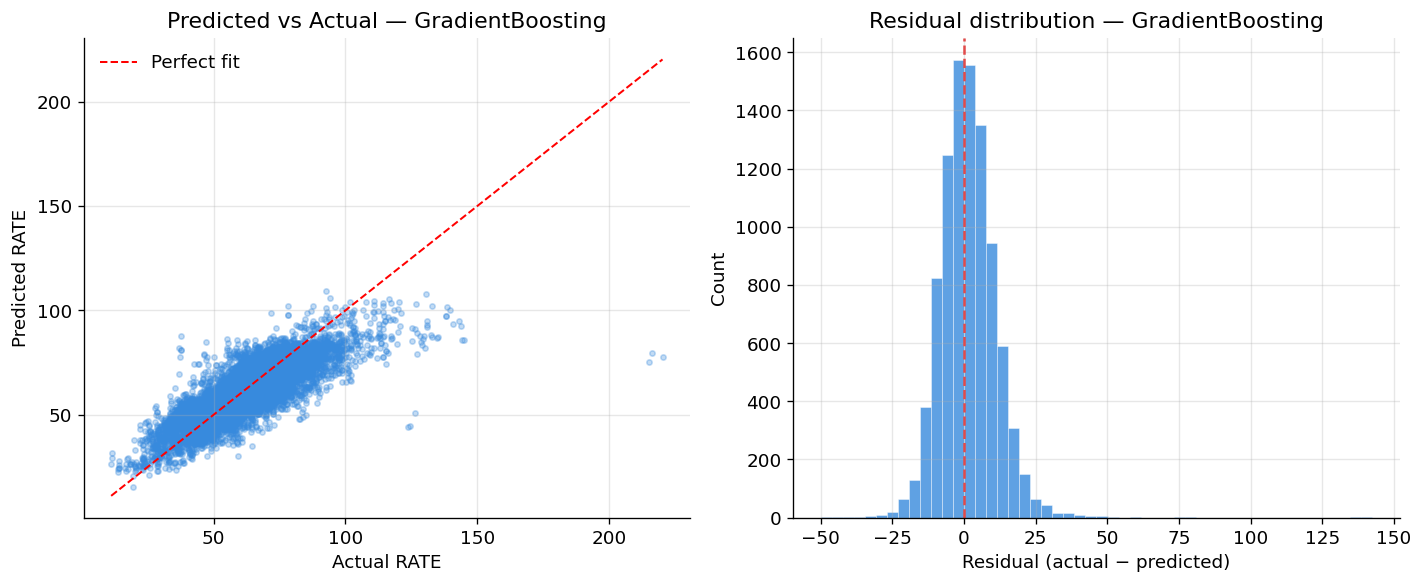

Saved → pred_vs_actual.png
  Bias (mean residual)   : 1.509
  Std residual           : 9.870


In [18]:
# ── Predicted vs Actual + Residuals (best model on test) ──────────────────
best_model_name = test_df_sorted.iloc[0]["Model"]
print(f"Best model: {best_model_name}")

if best_model_name.startswith("Ensemble"):
    test_best_pred = test_pred_ens
else:
    test_best_pred = trained_models[best_model_name].predict(X_test)

residuals = y_test.values - test_best_pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Predicted vs Actual
ax1.scatter(y_test, test_best_pred, alpha=0.3, s=10, color="#378ADD")
lo = min(y_test.min(), test_best_pred.min())
hi = max(y_test.max(), test_best_pred.max())
ax1.plot([lo, hi], [lo, hi], "r--", linewidth=1.2, label="Perfect fit")
ax1.set_xlabel(f"Actual {target}"); ax1.set_ylabel(f"Predicted {target}")
ax1.set_title(f"Predicted vs Actual — {best_model_name}")
ax1.legend(frameon=False)

# Residuals
ax2.hist(residuals, bins=50, color="#378ADD", alpha=0.8, edgecolor="white", linewidth=0.3)
ax2.axvline(0, color="#E24B4A", linewidth=1.5, linestyle="--")
ax2.set_xlabel("Residual (actual − predicted)")
ax2.set_ylabel("Count")
ax2.set_title(f"Residual distribution — {best_model_name}")

plt.tight_layout()
plt.savefig("pred_vs_actual.png", bbox_inches="tight")
plt.show()
print("Saved → pred_vs_actual.png")
print(f"  Bias (mean residual)   : {residuals.mean():.3f}")
print(f"  Std residual           : {residuals.std():.3f}")


## 9. Variable importance

In [19]:
feature_names = list(X.columns)

# ── 9a. Pearson |r| ────────────────────────────────────────────────────────
pearson_r = {f: abs(stats.pearsonr(df[f].dropna(), df[target][df[f].notna()])[0])
             for f in feature_names}
pearson_df = pd.Series(pearson_r, name="|Pearson r|").sort_values(ascending=False)
print("Pearson |r| with RATE:")
print(pearson_df.round(4).to_string())


Pearson |r| with RATE:
SMOKING    0.7513
PM25       0.4594
POVERTY    0.3628
SO2        0.3296
Year       0.1665
NO2        0.1658


In [20]:
# ── 9b. Permutation importance (best model) ────────────────────────────────
from sklearn.inspection import permutation_importance as perm_imp

if not best_model_name.startswith("Ensemble"):
    pipe_best = trained_models[best_model_name]
    perm_res  = perm_imp(pipe_best, X_test, y_test,
                         n_repeats=15, random_state=SEED, n_jobs=-1)
    perm_df = pd.DataFrame({
        "Feature":   feature_names,
        "Importance": perm_res.importances_mean,
        "Std":        perm_res.importances_std,
    }).sort_values("Importance", ascending=False)
    print(f"Permutation importance ({best_model_name}) on test set:")
    print(perm_df.round(4).to_string(index=False))
else:
    perm_df = None
    print("Permutation importance skipped for ensemble model.")


Permutation importance (GradientBoosting) on test set:
Feature  Importance    Std
SMOKING      0.6890 0.0105
   PM25      0.1145 0.0030
POVERTY      0.0945 0.0020
    NO2      0.0382 0.0018
    SO2      0.0292 0.0019
   Year      0.0000 0.0000


In [21]:
# ── 9c. Coefficient magnitude (linear models) ─────────────────────────────
coeff_results = {}
linear_models = [n for n in trained_models if n in ("OLS","Ridge","Lasso","ElasticNet")]

for nm in linear_models:
    pipe = trained_models[nm]
    coeff = pipe.named_steps["model"].coef_
    coeff_results[nm] = pd.Series(np.abs(coeff), index=feature_names, name=nm)

if coeff_results:
    coeff_df = pd.DataFrame(coeff_results)
    print("Absolute coefficient magnitude (linear models):")
    print(coeff_df.round(4).to_string())


Absolute coefficient magnitude (linear models):
          Lasso     OLS   Ridge
SMOKING  9.5574  9.5969  9.5965
POVERTY  2.6071  2.7153  2.7154
PM25     3.5747  3.6185  3.6185
NO2      0.3469  0.4603  0.4603
SO2      0.4044  0.4206  0.4207
Year     0.0229  0.1481  0.1481


In [22]:
# ── 9d. Tree-based feature importance (Gini / impurity) ───────────────────
tree_results = {}
tree_models = [n for n in trained_models if n in ("RandomForest","GradientBoosting")]

for nm in tree_models:
    pipe = trained_models[nm]
    fi   = pipe.named_steps["model"].feature_importances_
    tree_results[nm] = pd.Series(fi, index=feature_names, name=nm)

if tree_results:
    tree_df = pd.DataFrame(tree_results).sort_values(
        list(tree_results.keys())[0], ascending=False)
    print("Tree feature importance (normalised Gini):")
    print(tree_df.round(4).to_string())


Tree feature importance (normalised Gini):
         GradientBoosting  RandomForest
SMOKING            0.7595        0.3973
PM25               0.0832        0.1709
POVERTY            0.0746        0.1611
SO2                0.0478        0.1457
NO2                0.0304        0.0930
Year               0.0044        0.0320


Mean |SHAP| values (GradientBoosting):
SMOKING    9.5715
POVERTY    2.5689
PM25       2.4196
NO2        1.5648
SO2        1.0871
Year       0.6154


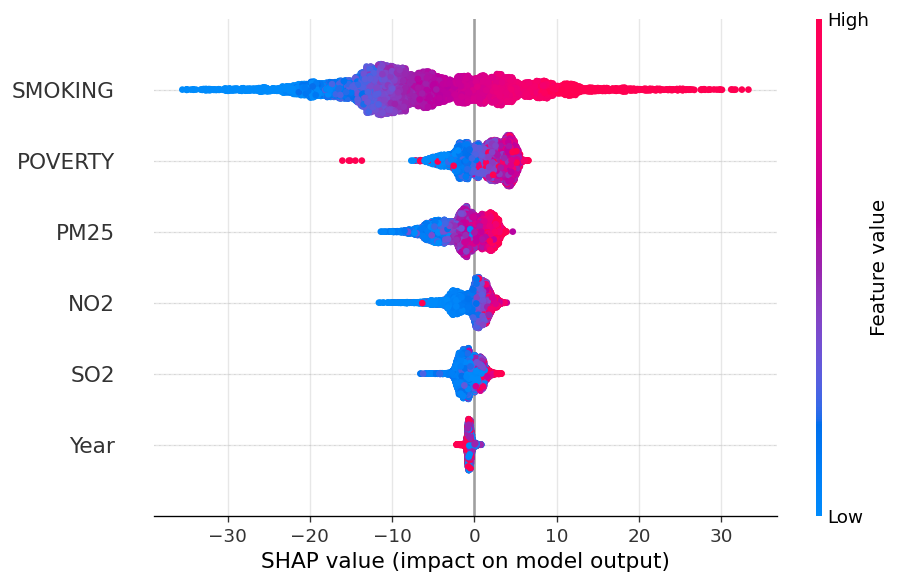

Saved → shap_summary.png


In [23]:
# ── 9e. SHAP values (best single model) ───────────────────────────────────
if HAS_SHAP and not best_model_name.startswith("Ensemble"):
    pipe_best = trained_models[best_model_name]
    Xt_test   = pipe_best.named_steps["scaler"].transform(X_test)
    inner     = pipe_best.named_steps["model"]

    if hasattr(inner, "predict"):
        try:
            if isinstance(inner, (RandomForestRegressor, GradientBoostingRegressor)):
                explainer = shap.TreeExplainer(inner)
                shap_vals = explainer.shap_values(Xt_test)
            else:
                explainer = shap.LinearExplainer(inner, Xt_test)
                shap_vals = explainer.shap_values(Xt_test)

            shap_df = pd.DataFrame(np.abs(shap_vals), columns=feature_names)
            print(f"Mean |SHAP| values ({best_model_name}):")
            print(shap_df.mean().sort_values(ascending=False).round(4).to_string())

            # SHAP summary plot
            shap.summary_plot(shap_vals, Xt_test, feature_names=feature_names,
                              show=False, plot_size=(8, 5))
            plt.tight_layout()
            plt.savefig("shap_summary.png", bbox_inches="tight")
            plt.show()
            print("Saved → shap_summary.png")
        except Exception as e:
            print(f"SHAP failed: {e}")
else:
    print("SHAP skipped (not installed or ensemble model selected).")


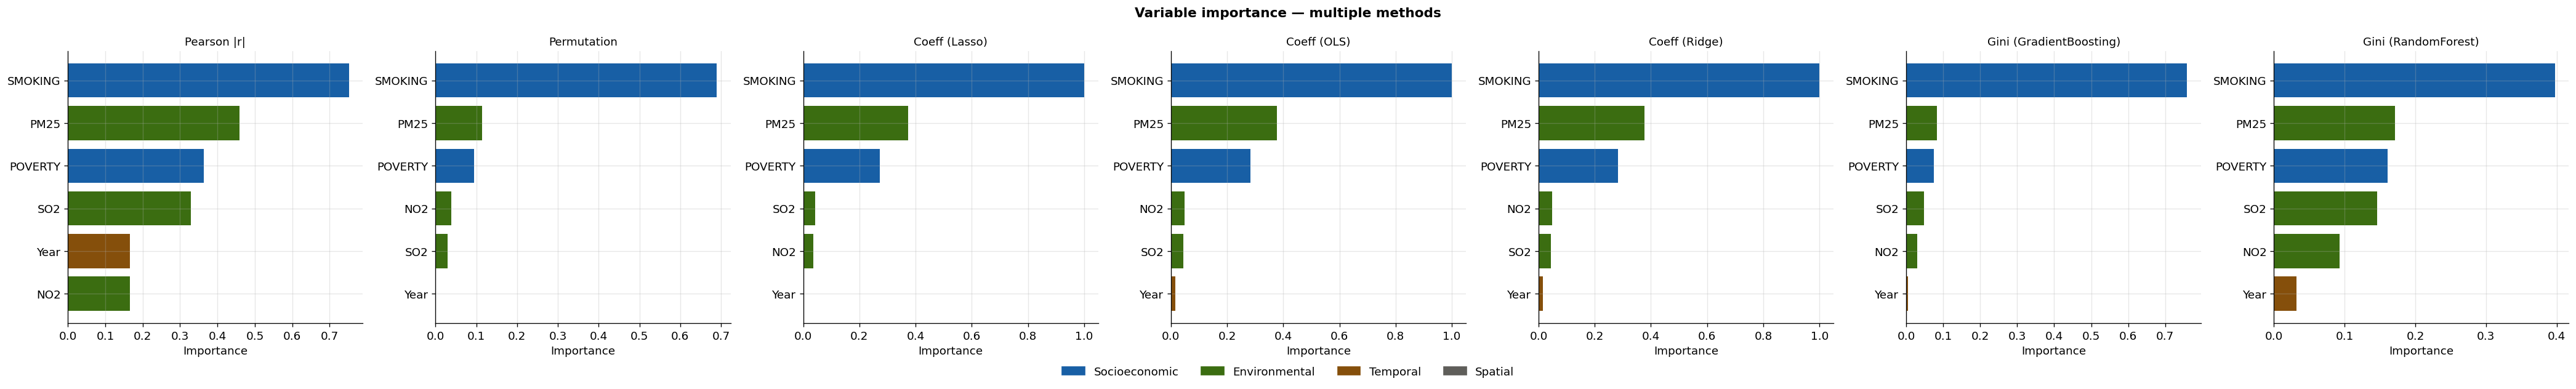

Saved → variable_importance.png


In [24]:
# ── 9f. Consolidated variable importance plot ──────────────────────────────
VAR_COLORS = {
    "SMOKING": "#185FA5", "POVERTY": "#185FA5",
    "PM25": "#3B6D11", "NO2": "#3B6D11", "SO2": "#3B6D11",
    "Year": "#854F0B", "X": "#5F5E5A", "Y": "#5F5E5A",
}
default_color = "#888780"

methods = {"Pearson |r|": pearson_df}
if perm_df is not None:
    methods["Permutation"] = perm_df.set_index("Feature")["Importance"]
for nm, s_coeff in coeff_results.items():
    methods[f"Coeff ({nm})"] = s_coeff / s_coeff.max()   # normalise
for nm, s_tree in tree_results.items():
    methods[f"Gini ({nm})"] = s_tree

n_methods = len(methods)
fig, axes = plt.subplots(1, n_methods, figsize=(5*n_methods, 5))
if n_methods == 1: axes = [axes]

for ax, (method_name, imp_series) in zip(axes, methods.items()):
    imp_sorted = imp_series.sort_values(ascending=True)
    colors = [VAR_COLORS.get(f, default_color) for f in imp_sorted.index]
    ax.barh(imp_sorted.index, imp_sorted.values, color=colors)
    ax.set_title(method_name, fontsize=11)
    ax.set_xlabel("Importance")

# Legend
from matplotlib.patches import Patch
legend_els = [
    Patch(color="#185FA5", label="Socioeconomic"),
    Patch(color="#3B6D11", label="Environmental"),
    Patch(color="#854F0B", label="Temporal"),
    Patch(color="#5F5E5A", label="Spatial"),
]
fig.legend(handles=legend_els, loc="lower center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, -0.05))
plt.suptitle("Variable importance — multiple methods", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("variable_importance.png", bbox_inches="tight")
plt.show()
print("Saved → variable_importance.png")


## 10. Importance stability across years

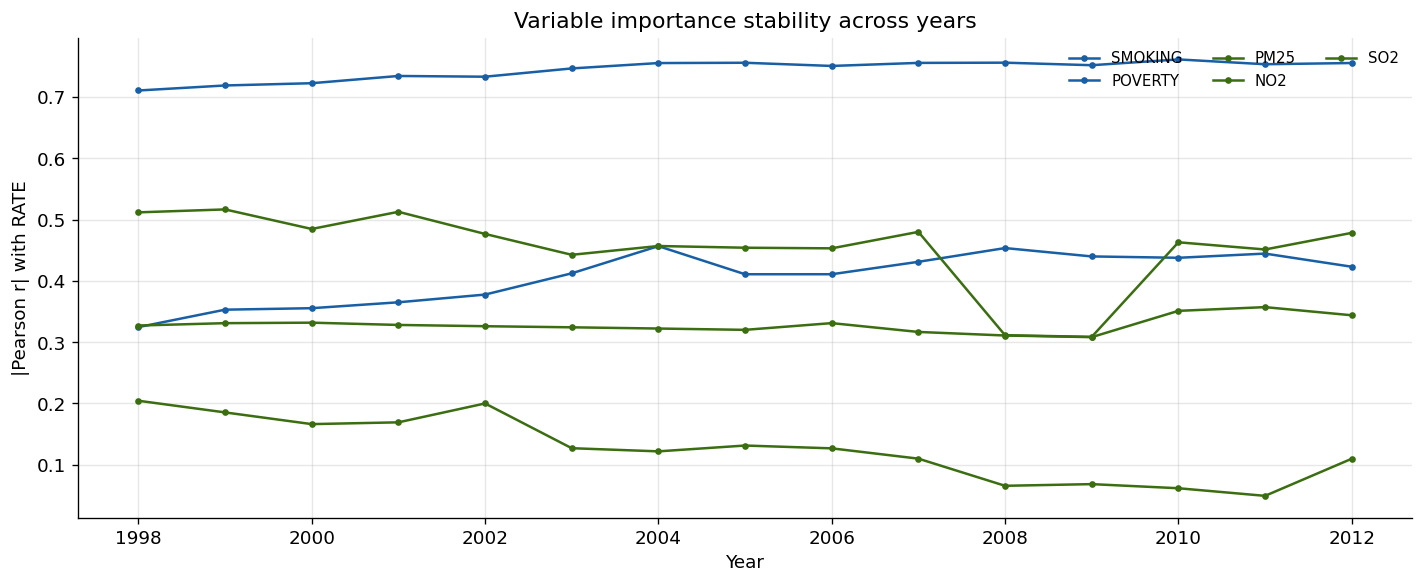

Saved → importance_stability.png

      SMOKING  POVERTY   PM25    NO2    SO2
Year                                       
1998    0.711    0.325  0.512  0.204  0.327
1999    0.719    0.353  0.517  0.185  0.331
2000    0.722    0.355  0.485  0.166  0.332
2001    0.734    0.365  0.513  0.169  0.328
2002    0.733    0.378  0.477  0.200  0.326
2003    0.747    0.412  0.442  0.127  0.324
2004    0.755    0.457  0.457  0.122  0.322
2005    0.756    0.411  0.454  0.131  0.320
2006    0.751    0.411  0.453  0.127  0.331
2007    0.756    0.431  0.480  0.110  0.317
2008    0.756    0.453  0.311  0.066  0.311
2009    0.752    0.440  0.309  0.068  0.308
2010    0.761    0.438  0.463  0.062  0.351
2011    0.753    0.444  0.451  0.049  0.357
2012    0.755    0.423  0.478  0.110  0.344


In [25]:
if tcol in df_raw.columns:
    year_corrs = {}
    for yr in sorted(df_raw[tcol].unique()):
        sub = df_raw[df_raw[tcol] == yr]
        yr_corr = {}
        for f in feature_names:
            if f in sub.columns and f != tcol:
                mask_ = sub[f].notna() & sub[target].notna()
                if mask_.sum() > 5:
                    r_, _ = stats.pearsonr(sub.loc[mask_, f], sub.loc[mask_, target])
                    yr_corr[f] = abs(r_)
        year_corrs[yr] = yr_corr

    stability_df = pd.DataFrame(year_corrs).T
    stability_df.index.name = tcol

    fig, ax = plt.subplots(figsize=(12, 5))
    for f in stability_df.columns:
        ax.plot(stability_df.index, stability_df[f],
                marker="o", markersize=3, linewidth=1.5,
                color=VAR_COLORS.get(f, default_color), label=f)
    ax.set_xlabel(tcol); ax.set_ylabel("|Pearson r| with RATE")
    ax.set_title("Variable importance stability across years")
    ax.legend(frameon=False, ncol=3, loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.savefig("importance_stability.png", bbox_inches="tight")
    plt.show()
    print("Saved → importance_stability.png")
    print()
    print(stability_df.round(3).to_string())
else:
    print("No temporal column — stability plot skipped.")


## 11. Export results

In [26]:
# ── Save all results to CSV ────────────────────────────────────────────────
val_df.to_csv("results_validation.csv", index=False)
test_df.to_csv("results_test.csv", index=False)
pearson_df.reset_index().rename(columns={"index":"Feature"}).to_csv("importance_pearson.csv", index=False)

print("Exported:")
print("  results_validation.csv")
print("  results_test.csv")
print("  importance_pearson.csv")
if perm_df is not None:
    perm_df.to_csv("importance_permutation.csv", index=False)
    print("  importance_permutation.csv")
if coeff_results:
    coeff_df.to_csv("importance_coefficients.csv")
    print("  importance_coefficients.csv")
if tree_results:
    tree_df.to_csv("importance_tree.csv")
    print("  importance_tree.csv")

print()
print("All done ✓")


Exported:
  results_validation.csv
  results_test.csv
  importance_pearson.csv
  importance_permutation.csv
  importance_coefficients.csv
  importance_tree.csv

All done ✓
